In [3]:
'''本代码为本科通识课深度学习入门演示，包含**水质状态分类（二分类任务）**与**帆船船体阻力回归预测（回归任务）**两个案例。
数据集预先快照存放于 GitHub 仓库，代码从 raw.githubusercontent 加载固定版本，避免第三方源更新导致结果漂移。
⚠️重要声明：水质案例的`正常/异常`标签为**教学演示人工构造标签，非官方环境水质评价标准**，不可用于真实水环境评估；
船舶阻力数据集来自 Mendeley 公开 CC BY 4.0 数据集，为拖曳水池试验实测数据。'''


'本代码为本科通识课深度学习入门演示，包含**水质状态分类（二分类任务）**与**帆船船体阻力回归预测（回归任务）**两个案例。\n数据集预先快照存放于 GitHub 仓库，代码从 raw.githubusercontent 加载固定版本，避免第三方源更新导致结果漂移。\n⚠️重要声明：水质案例的`正常/异常`标签为**教学演示人工构造标签，非官方环境水质评价标准**，不可用于真实水环境评估；\n船舶阻力数据集来自 Mendeley 公开 CC BY 4.0 数据集，为拖曳水池试验实测数据。'

本科人工智能通识课程：深度学习工程案例
TensorFlow版本: 2.20.0
可用GPU: []

说明：
GPU显示 [] 表示当前使用CPU。
本实验无需GPU。



案例A：水质状态智能识别

原始水质数据
数据集维度: (480, 23)


,Biosphere,id,river,site,weather,other_weather,start_comment,dissolved_oxgen_ppm,dissolved_oxygen_percent,time,...,Salinity Percentage,tds,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m)
0,Kruger 2 Canyons BR,Kubjaname Site 1,Kubjaname,Site 1,partly_cloudy,NaN,NaN,NaN,NaN,03/13/2024 08:31,...,NaN,NaN,NaN,NaN,pH reading indicates the water is NOT suitable...,NaN,-24.304498,30.504863,609.0,5.000
1,Kruger 2 Canyons BR,Kubjaname Site 3,Kubjaname,Site 3,partly_cloudy,NaN,NaN,NaN,224.7,03/13/2024 09:10,...,NaN,NaN,73.3,8.11,pH reading indicates the water is suitable for...,26.8,-24.302362,30.505223,622.8,4.800
2,Kruger 2 Canyons BR,Olifants Site 1,Olifants,Site 1,light_rain,NaN,NaN,NaN,146.7,03/14/2024 08:08,...,NaN,NaN,199.0,8.59,pH reading indicates the water is NOT suitable...,26.3,-24.361747,30.658613,467.4,4.100
3,Kruger 2 Canyons BR,Moetladimo Site 1,Moetladimo,Site 1,cloudy,NaN,NaN,NaN,125.7,03/19/2024 07:52,...,NaN,NaN,47.5,8.19,pH reading indicates the water is suitable for...,25.3,-24.258722,30.453870,610.2,3.814
4,Vhembe BR,Levubu River Lambani site 1,Levubu River,Lambani site 1,sunny,NaN,NaN,3.34,43.2,06/21/2024 10:51,...,NaN,NaN,128.6,7.91,pH reading indicates the water is suitable for...,18.0,-22.745560,30.884358,391.7,5.000



水质数据字段：
 0. Biosphere
 1. id
 2. river
 3. site
 4. weather
 5. other_weather
 6. start_comment
 7. dissolved_oxgen_ppm
 8. dissolved_oxygen_percent
 9. time
10. Nitrate
11. Phosphate
12. Solinity (Parts per Thousand)
13. Salinity Percentage
14. tds
15. Electrical Conductivity
16. PH
17. Irrigation Suitability
18. Air Temperature
19. latitude
20. longitude
21. Altitude (m)
22. Location Accuracy (m)

用于深度学习的水质特征：
✓ PH
✓ Air Temperature
✓ dissolved_oxgen_ppm
✓ Electrical Conductivity

各变量有效数据量：
PH                                  447 / 480
Air Temperature                     471 / 480
dissolved_oxgen_ppm                 295 / 480
Electrical Conductivity             472 / 480

数据清洗：
清洗前: 480
清洗后: 274
删除: 206

最终缺失值检查：
PH                         0
Air Temperature            0
dissolved_oxgen_ppm        0
Electrical Conductivity    0
dtype: int64

标签定义：
0 = Normal 正常
1 = Abnormal 异常

类别分布：
label
1    141
0    133
Name: count, dtype: int64


,PH,Air Temperature,dissolved_oxgen_ppm,Electrical Conductivity,label
4,7.91,18.0,3.34,128.6,1
8,8.42,18.1,1.29,53.8,1
11,8.42,18.1,1.29,53.8,1
15,8.28,17.0,2.59,171.7,1
16,8.28,17.0,2.39,171.7,1
27,8.29,26.1,1.58,231.0,1
28,7.60,26.6,1.06,138.0,1
29,6.44,23.8,0.45,120.4,1
30,6.44,23.8,0.45,120.4,1
31,6.44,23.8,0.45,120.4,1



X: (274, 4)
y: (274,)

训练集: (219, 4)
测试集: (55, 4)


水质深度神经网络


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)


开始训练水质模型...

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4800 - loss: 0.7337 - val_accuracy: 0.6591 - val_loss: 0.6665
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4971 - loss: 0.7175 - val_accuracy: 0.6818 - val_loss: 0.6597
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5486 - loss: 0.7022 - val_accuracy: 0.7273 - val_loss: 0.6511
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5714 - loss: 0.6903 - val_accuracy: 0.7273 - val_loss: 0.6446
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6343 - loss: 0.6787 - val_accuracy: 0.8182 - val_loss: 0.6380
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7371 - loss: 0.6685 - val_accuracy: 0.8409 - val_loss: 0.6331
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7543 - loss: 0.6588 - val_accuracy: 0.8409 - val_loss: 0.6293
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7543 - loss: 0.6499 - val_accuracy: 0.8409 - val

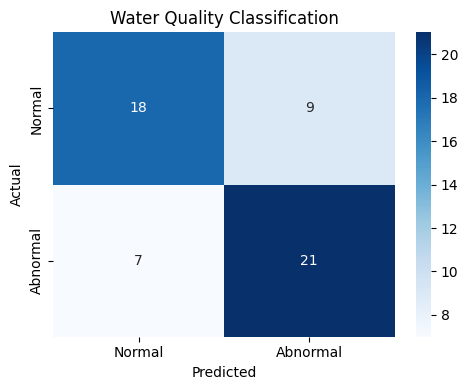

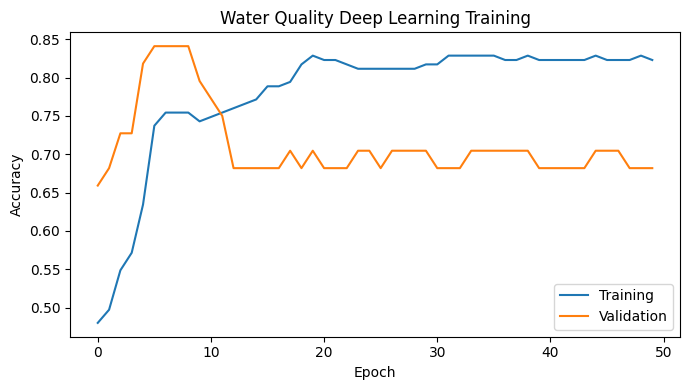




案例B：帆船船体阻力预测

船舶数据集维度： (1018, 21)


,Serie,Sysser,Rt*10^3/Delta,Rn,Fn,Cp,Cm,Cb,Cw,Lwl/Bwl,...,Lwl/Tc,Lwl/Vol^(1/3),Lcb/Lwl,Lcf/Lwl,Lcb/Lcf,Sc/Vol^(2/3),Aw/Vol^(2/3),Sc/Aw,Sc/Ax,Ax/Aw
0,DELFT Series,1,0.367054,9.870389e+06,0.099954,0.564414,0.64641,0.364842,0.688296,3.154574,...,12.594459,4.775348,-0.0229,-0.0333,0.687688,5.723559,4.975589,1.150328,15.426543,0.074568
1,DELFT Series,1,1.012178,1.480558e+07,0.149931,0.564414,0.64641,0.364842,0.688296,3.154574,...,12.594459,4.775348,-0.0229,-0.0333,0.687688,5.723559,4.975589,1.150328,15.426543,0.074568
2,DELFT Series,1,1.924250,1.974078e+07,0.199908,0.564414,0.64641,0.364842,0.688296,3.154574,...,12.594459,4.775348,-0.0229,-0.0333,0.687688,5.723559,4.975589,1.150328,15.426543,0.074568
3,DELFT Series,1,3.525939,2.467597e+07,0.249885,0.564414,0.64641,0.364842,0.688296,3.154574,...,12.594459,4.775348,-0.0229,-0.0333,0.687688,5.723559,4.975589,1.150328,15.426543,0.074568
4,DELFT Series,1,6.028577,2.964108e+07,0.300165,0.564414,0.64641,0.364842,0.688296,3.154574,...,12.594459,4.775348,-0.0229,-0.0333,0.687688,5.723559,4.975589,1.150328,15.426543,0.074568



船舶数据字段：
 0. Serie
 1. Sysser
 2. Rt*10^3/Delta
 3. Rn
 4. Fn
 5. Cp
 6. Cm
 7. Cb
 8. Cw
 9. Lwl/Bwl
10. Bwl/Tc
11. Lwl/Tc
12. Lwl/Vol^(1/3)
13. Lcb/Lwl
14. Lcf/Lwl
15. Lcb/Lcf
16. Sc/Vol^(2/3)
17. Aw/Vol^(2/3)
18. Sc/Aw
19. Sc/Ax
20. Ax/Aw

目标变量： Rt*10^3/Delta

目标变量统计：
count    1018.000000
mean       40.985945
std        48.554657
min         0.044559
25%         3.418217
50%        13.762475
75%        74.346257
max       252.422705
Name: Rt*10^3/Delta, dtype: float64

用于深度学习的船舶特征：
✓ Fn
✓ Cp
✓ Cm
✓ Cb
✓ Cw
✓ Lwl/Bwl
✓ Bwl/Tc

船舶数据清洗：
清洗前: 1018
清洗后: 1018
删除: 0

X shape: (1018, 7)
y shape: (1018,)

训练集: (814, 7)
测试集: (204, 7)


船舶阻力深度神经网络


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)


开始训练船舶阻力模型...

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8974 - mae: 0.7657 - val_loss: 0.6801 - val_mae: 0.6438
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5154 - mae: 0.5270 - val_loss: 0.3316 - val_mae: 0.3935
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2107 - mae: 0.3284 - val_loss: 0.1195 - val_mae: 0.2697
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0836 - mae: 0.2202 - val_loss: 0.0609 - val_mae: 0.1849
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0479 - mae: 0.1666 - val_loss: 0.0403 - val_mae: 0.1501
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0364 - mae: 0.1439 - val_loss: 0.0353 - val_mae: 0.1429
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0294 - mae: 0.1284 - val_loss: 0.0287 - val_mae: 0.1308
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0254 - mae: 0.1215 - val_loss: 0.0244 - val_mae: 0.1181
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms



船舶阻力回归模型评价
MAE  = 2.0466
RMSE = 2.9985
R²   = 0.9965


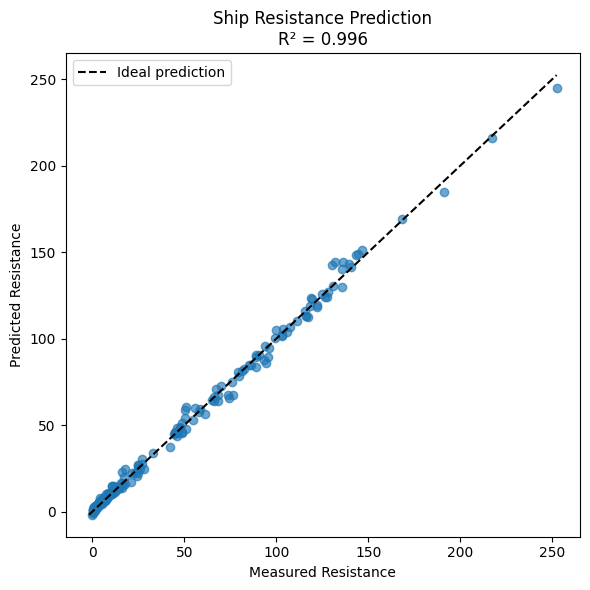

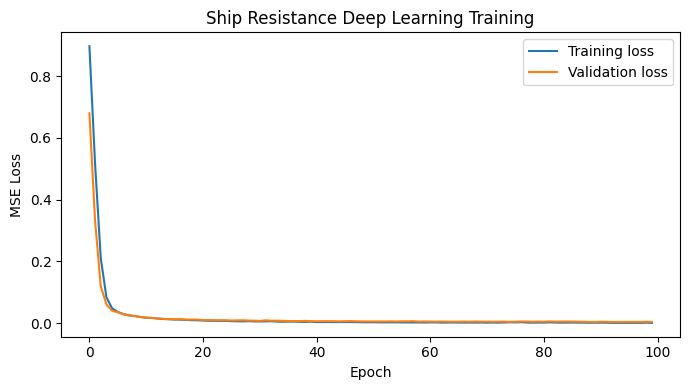



教材核心知识总结：分类 vs 回归


,项目,案例A：水质,案例B：船舶
0,任务类型,Classification,Regression
1,输入,水质监测指标,船体与流态参数
2,输出,正常 / 异常,连续阻力值
3,输出层,Sigmoid,Linear
4,损失函数,Binary Crossentropy,MSE
5,评价指标,Accuracy / Precision / Recall / F1,MAE / RMSE / R²
6,应用,水环境状态识别,船体阻力预测




最终实验结果

【案例A：水质分类】
Accuracy = 0.7091

【案例B：船舶阻力回归】
MAE  = 2.0466
RMSE = 2.9985
R²   = 0.9965


实验完成！


In [9]:
# ============================================================
# 教材配套深度学习工程案例
#
# 案例A：水质监测指标 → 水环境状态二分类
# 案例B：帆船船体几何/流态参数 → 船体阻力回归预测
#
# Google Colab
# CPU即可运行
# ============================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn tensorflow


# ============================================================
# 0. 导入工具
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")


print("=" * 70)
print("本科人工智能通识课程：深度学习工程案例")
print("=" * 70)

print("TensorFlow版本:", tf.__version__)
print("可用GPU:", tf.config.list_physical_devices("GPU"))

print("\n说明：")
print("GPU显示 [] 表示当前使用CPU。")
print("本实验无需GPU。")


# ============================================================
# ============================================================
# 案例A：水质状态智能识别
# ============================================================
# ============================================================

print("\n\n")
print("=" * 70)
print("案例A：水质状态智能识别")
print("=" * 70)


# ============================================================
# A1. 读取水质数据
# ============================================================

WATER_FILE = (
    "citizen-science-water-quality-monitoring-"
    "wq-parameters_local_time.csv"
)

if not os.path.exists(WATER_FILE):

    raise FileNotFoundError(
        "\n找不到水质数据文件！\n"
        "请上传：\n"
        f"{WATER_FILE}"
    )


df_water = pd.read_csv(WATER_FILE)

print("\n原始水质数据")
print("数据集维度:", df_water.shape)

display(df_water.head())


# ============================================================
# A2. 查看字段
# ============================================================

print("\n水质数据字段：")

for i, c in enumerate(df_water.columns):

    print(f"{i:2d}. {c}")


# ============================================================
# A3. 明确选择有效水质特征
# ============================================================
#
# 根据实际数据检查结果：
#
# PH                         447 / 480
# Air Temperature            471 / 480
# dissolved_oxgen_ppm        295 / 480
# Electrical Conductivity    472 / 480
#
# 以下字段全部为空：
#
# Salinity Percentage          0 / 480
# Nitrate                      0 / 480
# Phosphate                    0 / 480
#
# 因此不把这些全空字段送入神经网络。
# ============================================================

water_features = [

    "PH",

    "Air Temperature",

    "dissolved_oxgen_ppm",

    "Electrical Conductivity"

]


print("\n用于深度学习的水质特征：")

for c in water_features:

    print("✓", c)


# ============================================================
# A4. 检查字段
# ============================================================

missing_columns = [

    c for c in water_features

    if c not in df_water.columns

]


if len(missing_columns) > 0:

    raise ValueError(
        f"缺少字段：{missing_columns}"
    )


# ============================================================
# A5. 转换为数值
# ============================================================

df_w = df_water[
    water_features
].copy()


for c in water_features:

    df_w[c] = pd.to_numeric(

        df_w[c],

        errors="coerce"

    )


# ============================================================
# A6. 查看有效数据量
# ============================================================

print("\n各变量有效数据量：")

for c in water_features:

    valid = df_w[c].notna().sum()

    print(

        f"{c:35s}"

        f"{valid:4d} / {len(df_w)}"

    )


# ============================================================
# A7. 删除关键变量缺失数据
# ============================================================
#
# PH 和 DO 同时参与教学标签构造，
# 因此这两个变量必须存在。
# ============================================================

before = len(df_w)


df_w = df_w.dropna(

    subset=[

        "PH",

        "dissolved_oxgen_ppm"

    ]

)


after = len(df_w)


print("\n数据清洗：")

print("清洗前:", before)

print("清洗后:", after)

print("删除:", before - after)


# ============================================================
# A8. 其他缺失值使用中位数填充
# ============================================================

for c in water_features:

    if c not in [

        "PH",

        "dissolved_oxgen_ppm"

    ]:

        df_w[c] = df_w[c].fillna(

            df_w[c].median()

        )


# ============================================================
# A9. 最终检查 NaN
# ============================================================

print("\n最终缺失值检查：")

print(
    df_w[water_features].isna().sum()
)


if df_w[
    water_features
].isna().sum().sum() > 0:

    raise ValueError(
        "水质输入数据仍存在NaN，请检查数据。"
    )


# ============================================================
# A10. 构造教学标签
# ============================================================
#
# 教学规则：
#
# pH < 6.5       → 异常
# pH > 8.5       → 异常
# DO < 5 mg/L    → 异常
#
# 这里只用于演示监督学习分类。
# 不是国家/地方水质评价标准。
# ============================================================

df_w["label"] = (

    (df_w["PH"] < 6.5)

    |

    (df_w["PH"] > 8.5)

    |

    (df_w["dissolved_oxgen_ppm"] < 5.0)

).astype(int)


print("\n标签定义：")

print("0 = Normal 正常")

print("1 = Abnormal 异常")


print("\n类别分布：")

print(
    df_w["label"].value_counts()
)


if df_w["label"].nunique() != 2:

    raise ValueError(
        "当前数据无法形成有效二分类任务。"
    )


# ============================================================
# A11. 查看处理后的数据
# ============================================================

display(
    df_w.head(10)
)


# ============================================================
# A12. 构造 X / y
# ============================================================

X_water = df_w[
    water_features
].values


y_water = df_w[
    "label"
].values


print("\nX:", X_water.shape)

print("y:", y_water.shape)


# ============================================================
# A13. 训练集 / 测试集
# ============================================================

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(

    X_water,

    y_water,

    test_size=0.20,

    random_state=42,

    stratify=y_water

)


print("\n训练集:", X_train_w.shape)

print("测试集:", X_test_w.shape)


# ============================================================
# A14. 标准化
# ============================================================

scaler_water = StandardScaler()


X_train_w = scaler_water.fit_transform(
    X_train_w
)


X_test_w = scaler_water.transform(
    X_test_w
)


# 最终安全检查

if not np.isfinite(X_train_w).all():

    raise ValueError(
        "训练数据包含 NaN 或 Inf。"
    )

if not np.isfinite(X_test_w).all():

    raise ValueError(
        "测试数据包含 NaN 或 Inf。"
    )


# ============================================================
# A15. 建立深度神经网络
# ============================================================

print("\n")
print("=" * 70)
print("水质深度神经网络")
print("=" * 70)


model_water = keras.Sequential([

    layers.Input(
        shape=(X_train_w.shape[1],)
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])


model_water.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)


model_water.summary()


# ============================================================
# A16. 模型训练
# ============================================================

print("\n开始训练水质模型...\n")


history_water = model_water.fit(

    X_train_w,

    y_train_w,

    validation_split=0.20,

    epochs=50,

    batch_size=32,

    verbose=1

)


# ============================================================
# A17. 预测
# ============================================================

y_prob_water = model_water.predict(

    X_test_w,

    verbose=0

).ravel()


y_pred_water = (

    y_prob_water >= 0.5

).astype(int)


# ============================================================
# A18. 评价
# ============================================================

accuracy_water = accuracy_score(

    y_test_w,

    y_pred_water

)


print("\n")
print("=" * 70)
print("水质分类模型评价")
print("=" * 70)


print(

    f"Accuracy = {accuracy_water:.4f}"

)


print("\nClassification Report:")


print(

    classification_report(

        y_test_w,

        y_pred_water,

        target_names=[

            "Normal 正常",

            "Abnormal 异常"

        ],

        zero_division=0

    )

)


# ============================================================
# A19. 混淆矩阵
# ============================================================

cm = confusion_matrix(

    y_test_w,

    y_pred_water

)


plt.figure(

    figsize=(5, 4)

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[

        "Normal",

        "Abnormal"

    ],

    yticklabels=[

        "Normal",

        "Abnormal"

    ]

)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Water Quality Classification"
)

plt.tight_layout()

plt.show()


# ============================================================
# A20. 训练曲线
# ============================================================

plt.figure(

    figsize=(7, 4)

)


plt.plot(

    history_water.history["accuracy"],

    label="Training"

)


plt.plot(

    history_water.history["val_accuracy"],

    label="Validation"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Water Quality Deep Learning Training"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# ============================================================
# 案例B：船体阻力深度学习回归
# ============================================================
# ============================================================

print("\n\n")

print("=" * 70)

print(
    "案例B：帆船船体阻力预测"
)

print("=" * 70)


# ============================================================
# B1. 读取船舶数据
# ============================================================

SHIP_FILE = (
    "Sailboat Hull Resistance Dataset V01.csv"
)


if not os.path.exists(SHIP_FILE):

    raise FileNotFoundError(

        "\n找不到船舶数据文件！\n"

        "请上传：\n"

        f"{SHIP_FILE}"

    )


df_ship = pd.read_csv(

    SHIP_FILE,

    sep=";"

)


print(

    "\n船舶数据集维度：",

    df_ship.shape

)


display(
    df_ship.head()
)


# ============================================================
# B2. 查看字段
# ============================================================

print("\n船舶数据字段：")

for i, c in enumerate(
    df_ship.columns
):

    print(
        f"{i:2d}. {c}"
    )


# ============================================================
# B3. 正确设置目标变量
# ============================================================
#
# 实际数据字段：
#
# Rt*10^3/Delta
#
# 注意：
# 不是：
# Rt/Delta * 10^3
# ============================================================

TARGET = "Rt*10^3/Delta"


if TARGET not in df_ship.columns:

    raise ValueError(

        f"找不到目标变量：{TARGET}"

    )


print(
    "\n目标变量：",
    TARGET
)


print(
    "\n目标变量统计："
)


print(
    df_ship[TARGET].describe()
)


# ============================================================
# B4. 选择教学特征
# ============================================================

candidate_ship_features = [

    "Fn",

    "Re",

    "Cp",

    "Cm",

    "Cb",

    "Cw",

    "Lwl/Bwl",

    "Bwl/Tc"

]


ship_features = [

    c

    for c in candidate_ship_features

    if c in df_ship.columns

]


print(
    "\n用于深度学习的船舶特征："
)


for c in ship_features:

    print(
        "✓",
        c
    )


# ============================================================
# B5. 建立船舶建模数据
# ============================================================

df_s = df_ship[

    ship_features + [TARGET]

].copy()


# 转换为数值

for c in df_s.columns:

    df_s[c] = pd.to_numeric(

        df_s[c],

        errors="coerce"

    )


before_ship = len(df_s)


df_s = df_s.dropna()


after_ship = len(df_s)


print("\n船舶数据清洗：")

print(
    "清洗前:",
    before_ship
)

print(
    "清洗后:",
    after_ship
)

print(
    "删除:",
    before_ship - after_ship
)


# ============================================================
# B6. X / y
# ============================================================

X_ship = df_s[
    ship_features
].values


y_ship = df_s[
    TARGET
].values


print(
    "\nX shape:",
    X_ship.shape
)

print(
    "y shape:",
    y_ship.shape
)


# ============================================================
# B7. 训练集 / 测试集
# ============================================================

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(

    X_ship,

    y_ship,

    test_size=0.20,

    random_state=42

)


print(
    "\n训练集:",
    X_train_s.shape
)

print(
    "测试集:",
    X_test_s.shape
)


# ============================================================
# B8. 标准化
# ============================================================

scaler_x_ship = StandardScaler()

scaler_y_ship = StandardScaler()


X_train_s = scaler_x_ship.fit_transform(

    X_train_s

)


X_test_s = scaler_x_ship.transform(

    X_test_s

)


y_train_s_scaled = scaler_y_ship.fit_transform(

    y_train_s.reshape(
        -1,
        1
    )

).ravel()


y_test_s_scaled = scaler_y_ship.transform(

    y_test_s.reshape(
        -1,
        1
    )

).ravel()


# 安全检查

if not np.isfinite(X_train_s).all():

    raise ValueError(
        "船舶训练数据存在 NaN 或 Inf。"
    )


if not np.isfinite(y_train_s_scaled).all():

    raise ValueError(
        "船舶目标变量存在 NaN 或 Inf。"
    )


# ============================================================
# B9. 建立深度神经网络
# ============================================================

print("\n")
print("=" * 70)

print(
    "船舶阻力深度神经网络"
)

print("=" * 70)


model_ship = keras.Sequential([

    layers.Input(

        shape=(

            X_train_s.shape[1],

        )

    ),

    layers.Dense(

        64,

        activation="relu"

    ),

    layers.Dense(

        32,

        activation="relu"

    ),

    layers.Dense(

        16,

        activation="relu"

    ),

    layers.Dense(

        1

    )

])


model_ship.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)


model_ship.summary()


# ============================================================
# B10. 模型训练
# ============================================================

print("\n开始训练船舶阻力模型...\n")


history_ship = model_ship.fit(

    X_train_s,

    y_train_s_scaled,

    validation_split=0.20,

    epochs=100,

    batch_size=32,

    verbose=1

)


# ============================================================
# B11. 预测
# ============================================================

y_pred_scaled = model_ship.predict(

    X_test_s,

    verbose=0

).ravel()


# 恢复原始量纲

y_pred_ship = scaler_y_ship.inverse_transform(

    y_pred_scaled.reshape(

        -1,

        1

    )

).ravel()


# ============================================================
# B12. 模型评价
# ============================================================

mae_ship = mean_absolute_error(

    y_test_s,

    y_pred_ship

)


rmse_ship = np.sqrt(

    mean_squared_error(

        y_test_s,

        y_pred_ship

    )

)


r2_ship = r2_score(

    y_test_s,

    y_pred_ship

)


print("\n")
print("=" * 70)

print(
    "船舶阻力回归模型评价"
)

print("=" * 70)


print(

    f"MAE  = {mae_ship:.4f}"

)


print(

    f"RMSE = {rmse_ship:.4f}"

)


print(

    f"R²   = {r2_ship:.4f}"

)


# ============================================================
# B13. 实测值 vs 预测值
# ============================================================

plt.figure(

    figsize=(6, 6)

)


plt.scatter(

    y_test_s,

    y_pred_ship,

    alpha=0.65

)


min_value = min(

    y_test_s.min(),

    y_pred_ship.min()

)


max_value = max(

    y_test_s.max(),

    y_pred_ship.max()

)


plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    "--k",

    label="Ideal prediction"

)


plt.xlabel(
    "Measured Resistance"
)

plt.ylabel(
    "Predicted Resistance"
)


plt.title(

    "Ship Resistance Prediction\n"

    f"R² = {r2_ship:.3f}"

)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# B14. 训练损失曲线
# ============================================================

plt.figure(

    figsize=(7, 4)

)


plt.plot(

    history_ship.history["loss"],

    label="Training loss"

)


plt.plot(

    history_ship.history["val_loss"],

    label="Validation loss"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Ship Resistance Deep Learning Training"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 32. 两种AI任务对比
# ============================================================

print("\n")
print("=" * 70)

print(
    "教材核心知识总结：分类 vs 回归"
)

print("=" * 70)


summary_table = pd.DataFrame({

    "项目": [

        "任务类型",

        "输入",

        "输出",

        "输出层",

        "损失函数",

        "评价指标",

        "应用"

    ],

    "案例A：水质": [

        "Classification",

        "水质监测指标",

        "正常 / 异常",

        "Sigmoid",

        "Binary Crossentropy",

        "Accuracy / Precision / Recall / F1",

        "水环境状态识别"

    ],

    "案例B：船舶": [

        "Regression",

        "船体与流态参数",

        "连续阻力值",

        "Linear",

        "MSE",

        "MAE / RMSE / R²",

        "船体阻力预测"

    ]

})


display(
    summary_table
)


# ============================================================
# 33. 最终结果
# ============================================================

print("\n")
print("=" * 70)

print(
    "最终实验结果"
)

print("=" * 70)


print(
    "\n【案例A：水质分类】"
)

print(
    f"Accuracy = {accuracy_water:.4f}"
)


print(
    "\n【案例B：船舶阻力回归】"
)

print(
    f"MAE  = {mae_ship:.4f}"
)

print(
    f"RMSE = {rmse_ship:.4f}"
)

print(
    f"R²   = {r2_ship:.4f}"
)


print("\n")
print("=" * 70)

print(
    "实验完成！"
)

print("=" * 70)